# Testing Notebook 
This notebook is to test our class and functions 

## Testing class functionality

In [1]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random, importlib
import matplotlib.pyplot as plt
from typing import List

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode

# import our functions 
os.chdir("../preprocessing")
import tumor_dataset

importlib.reload(tumor_dataset)
from tumor_dataset import Dataset

below is code to test our loading and cashing functionalities, not neccarily our functions themselves

In [3]:
d = Dataset(data_path="../../data/raw_data/useable_data")
d.convert_binary_to_coco()
# d.preprocess_images()
# d.split_train_val_test(75, 10, 15)
# d.cashe_data()

Init Dataset
Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/test/masks
Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/test/masks
Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgd/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgd/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents

Data loaded from cache.
RGB training images: 181, validation: 25, testing: 37
Depth training images: 181, validation: 25, testing: 37
RGD training images: 181, validation: 25, testing: 37
Training masks: 180, validation: 24, testing: 36


Text(0.5, 1.0, 'mask')

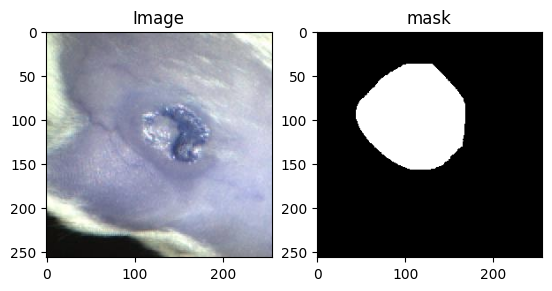

In [5]:
train_images, train_masks, val_images, val_masks, test_images, test_masks = d.load_data(rgb=True)
f, ax = plt.subplots(1,2)
num = random.randint(0, len(train_images))
ax[0].imshow(train_images[num])
ax[0].set_title("Image")
ax[1].imshow(train_masks[num], cmap="gray")
ax[1].set_title("mask")

now we are going to convert the binary image to coco json 

In [6]:
from detectron2.data.datasets import register_coco_instances
d.convert_binary_to_coco()

register_coco_instances("my_dataset_train", {}, "../../data/processed_data/rgb/train/images/train.json", "../../data/processed_data/rgb/train/images/")
register_coco_instances("my_dataset_val", {}, "../../data/processed_data/rgb/val/images/val.json", "../../data/processed_data/rgb/val/images/")
register_coco_instances("my_dataset_test", {}, "../../data/processed_data/rgb/test/images/test.json", "../../data/processed_data/rgb/test/images/")

Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/test/masks
Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/test/masks
Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgd/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgd/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/p

In [7]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[07/02 06:39:17 d2.data.datasets.coco]: Loaded 180 images in COCO format from ../../data/processed_data/rgb/train/images/train.json
[07/02 06:39:17 d2.data.datasets.coco]: Loaded 24 images in COCO format from ../../data/processed_data/rgb/val/images/val.json
[07/02 06:39:17 d2.data.datasets.coco]: Loaded 36 images in COCO format from ../../data/processed_data/rgb/test/images/test.json


test annotations at a glance

Image file: ../../data/processed_data/rgb/val/images/val_0.jpg
Mask file: ../../data/processed_data/val/masks/Tumor/val_0.png
Failed to load mask: ../../data/processed_data/val/masks/Tumor/val_0.png


[ WARN:0@187.444] global loadsave.cpp:268 findDecoder imread_('../../data/processed_data/val/masks/Tumor/val_0.png'): can't open/read file: check file path/integrity


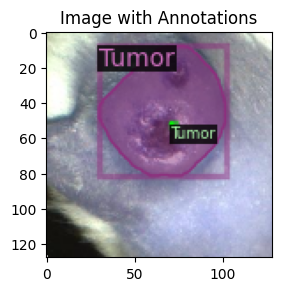

In [55]:
mask_folder = "../../data/processed_data/val/masks/Tumor"  # Update with your binary mask folder path

for d in random.sample(val_dataset_dicts, 1):
    # Load the image
    img = cv2.imread(d["file_name"])

    print(f"Image file: {d['file_name']}")
    
    # Check if the image was successfully loaded
    if img is None:
        print(f"Failed to load image: {d['file_name']}")
        continue

    # Visualize the image with annotations
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)

    # Display the annotated image
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.title("Image with Annotations")

    # Load the corresponding binary mask
    image_base_name = os.path.basename(d["file_name"]).split(".")[0]  # Get base name of the image
    mask_path = os.path.join(mask_folder, f"{image_base_name}.png")  # Assuming masks have .jpg extension

    print(f"Mask file: {mask_path}")
    
    # Load the binary mask
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Check if the mask was successfully loaded
    if mask_img is None:
        print(f"Failed to load mask: {mask_path}")
        continue

    # Display the binary mask
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    plt.imshow(mask_img, cmap="gray")
    plt.title("Binary Mask")

    plt.show()  # Display the images side by side

## Testing Data functions 

this section is mainly for testing the create binary mask function, where the issue is that some colors from the highlighted region are being left out

In [ ]:
"""
below is a copy of the used function for testing 
currently there are two ranges, and the colors in both of those ranges are combined 
the two ranges create the mask
"""
def create_binary_masks(image_array: List[np.ndarray]) -> List[np.ndarray]:
    binary_masks = []
    
    for image in image_array:
        if image.ndim == 2:
            image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        elif image.shape[2] != 3:
            raise ValueError("Input image must have 3 channels (BGR format).")
        else:
            image_color = image
        
        hsv = cv2.cvtColor(image_color, cv2.COLOR_BGR2HSV)

        lower_red1 = np.array([0, 150, 50])
        upper_red1 = np.array([10, 255, 255])
        lower_red2 = np.array([170, 150, 50])
        upper_red2 = np.array([180, 255, 255])

        # Create masks for the red color
        mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

        # Combine the two masks
        mask = cv2.bitwise_or(mask1, mask2)
        
        binary_masks.append(mask)
        
    return binary_masks

find an image that has a bad mask for sampling. For this case, we used image 118

image sampled: 136


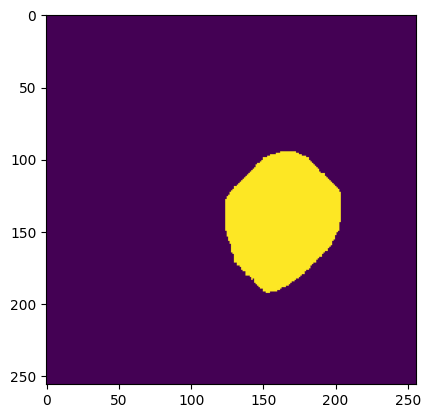

In [85]:
num = random.randint(0, len(train_masks))
print("image sampled:", num)
plt.imshow(train_masks[num])
plt.show()

Now we check that image to see

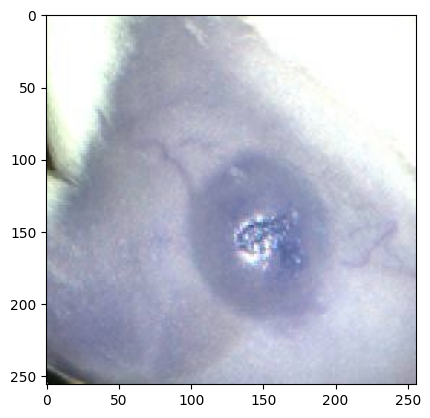

In [86]:
plt.imshow(train_images[num])